In [3]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
# Download stock data (Apple as example)
data = yf.download("AAPL", start="2021-01-01", end="2026-03-14")

print(data.head())

[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open     Volume
Ticker            AAPL        AAPL        AAPL        AAPL       AAPL
Date                                                                 
2021-01-04  125.856720  129.941395  123.279481  129.853870  143301900
2021-01-05  127.412766  128.122732  124.903605  125.350981   97664900
2021-01-06  123.123840  127.451658  122.909880  124.213090  155088000
2021-01-07  127.325218  128.015730  124.349242  124.835513  109578200
2021-01-08  128.424210  128.988286  126.654176  128.793766  105158200


In [7]:
import yfinance as yf
import pandas as pd

# Define the stock symbol (Apple as example)
symbol = "AAPL"

# Define start and end dates (5 years)
start_date = "2021-03-14"
end_date = "2026-03-14"

# Download daily data
data = yf.download(symbol, start=start_date, end=end_date, interval="1d")

# Show first 5 rows to verify
print(data.head())

# Save to CSV (optional)
data.to_csv(f"{symbol}_5years.csv")

[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open     Volume
Ticker            AAPL        AAPL        AAPL        AAPL       AAPL
Date                                                                 
2021-03-15  120.765717  120.775459  117.288552  118.252813   92403800
2021-03-16  122.304634  123.911728  121.476739  122.431251  115227900
2021-03-17  121.515678  122.587072  119.158604  120.824143  111932600
2021-03-18  117.395660  119.976750  117.191122  119.684548  121229700
2021-03-19  116.869728  118.272284  116.567792  116.782072  185549500


In [8]:
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    print(data)

Price            Close        High         Low        Open     Volume
Ticker            AAPL        AAPL        AAPL        AAPL       AAPL
Date                                                                 
2021-03-15  120.765717  120.775459  117.288552  118.252813   92403800
2021-03-16  122.304634  123.911728  121.476739  122.431251  115227900
2021-03-17  121.515678  122.587072  119.158604  120.824143  111932600
2021-03-18  117.395660  119.976750  117.191122  119.684548  121229700
2021-03-19  116.869728  118.272284  116.567792  116.782072  185549500
2021-03-22  120.181305  120.648826  117.132702  117.200881  111912300
2021-03-23  119.353416  121.009206  118.963817  120.122874   95467100
2021-03-24  116.967110  119.704042  116.947633  119.626121   88530500
2021-03-25  117.454140  118.496322  115.905490  116.431449   98844700
2021-03-26  118.058006  118.320989  115.827555  117.220369   94071200
2021-03-29  118.233337  119.392395  117.590504  118.486578   80819200
2021-03-30  116.7820

In [10]:
#Computing the daily range(high - low)
data['Daily_Range'] = data['High'] - data['Low']

print(data[['High','Low','Daily_Range']].head())

Price             High         Low Daily_Range
Ticker            AAPL        AAPL            
Date                                          
2021-03-15  120.775459  117.288552         NaN
2021-03-16  123.911728  121.476739         NaN
2021-03-17  122.587072  119.158604         NaN
2021-03-18  119.976750  117.191122         NaN
2021-03-19  118.272284  116.567792         NaN


In [11]:
print(data.dtypes)

Price        Ticker
Close        AAPL      float64
High         AAPL      float64
Low          AAPL      float64
Open         AAPL      float64
Volume       AAPL        int64
Daily_Range            float64
dtype: object


In [14]:
#print the data columns
print(data.columns)

MultiIndex([(      'Close', 'AAPL'),
            (       'High', 'AAPL'),
            (        'Low', 'AAPL'),
            (       'Open', 'AAPL'),
            (     'Volume', 'AAPL'),
            ('Daily_Range',     '')],
           names=['Price', 'Ticker'])


In [21]:
data['Daily_Range'] = data['High', 'AAPL'] - data['Low', 'AAPL']

print(type(data['Daily_Range']))

<class 'pandas.core.series.Series'>


In [26]:
data = data.dropna(subset=[ "'High','AAPL'","'Low', 'AAPL'","Daily_Range"])

KeyError: ["'High','AAPL'", "'Low', 'AAPL'", 'Daily_Range']

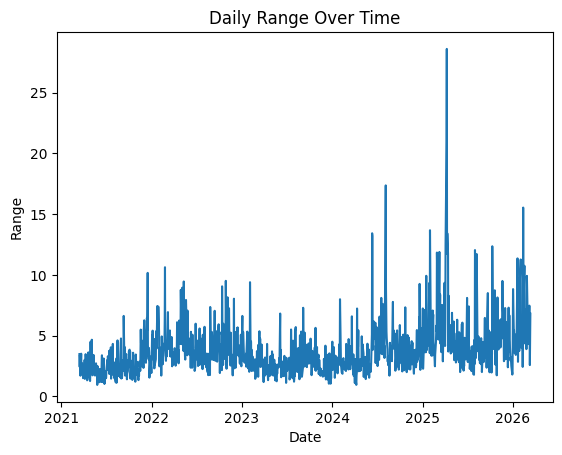

In [27]:
import matplotlib.pyplot as plt

plt.plot(data['Daily_Range'])
plt.title('Daily Range Over Time')
plt.xlabel('Date')
plt.ylabel('Range')
plt.show()

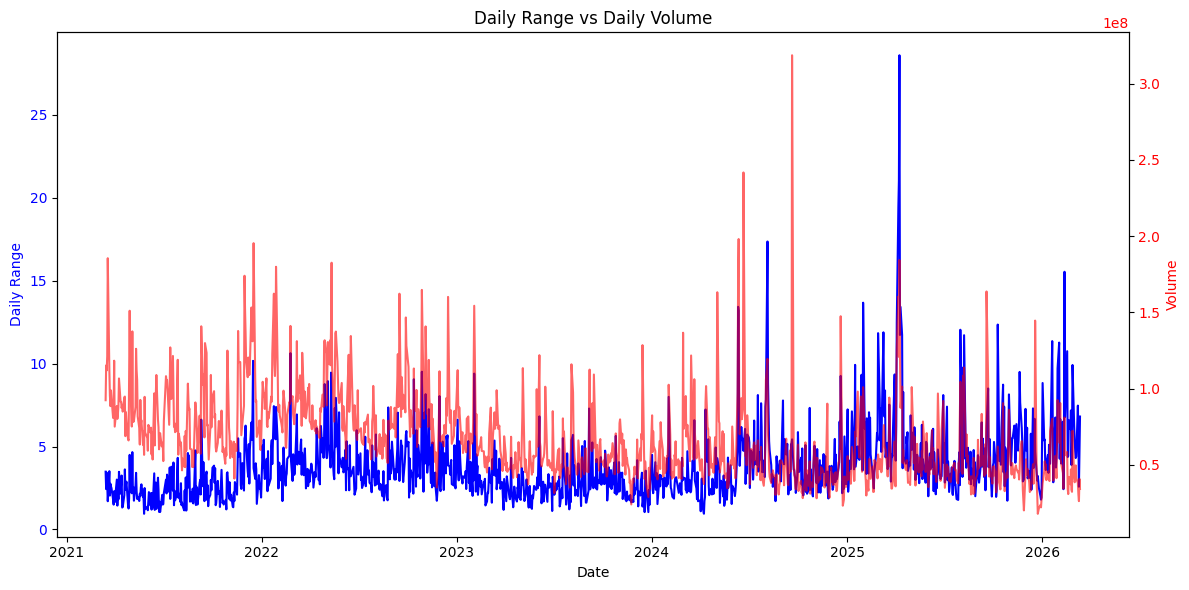

In [29]:
import matplotlib.pyplot as plt

# Create figure and axis
fig, ax1 = plt.subplots(figsize=(12,6))

# Plot Daily Range on left y-axis
ax1.plot(data.index, data['Daily_Range'], color='blue', label='Daily Range')
ax1.set_xlabel('Date')
ax1.set_ylabel('Daily Range', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Create second y-axis for Volume
ax2 = ax1.twinx()
ax2.plot(data.index, data['Volume'], color='red', label='Daily Volume', alpha=0.6)
ax2.set_ylabel('Volume', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Add title and show
plt.title('Daily Range vs Daily Volume')
fig.tight_layout()
plt.show()

In [30]:
#checkimg if transformation is needed i.e checking for skewness

skewness = data['Daily_Range'].skew()
print("Skewness of Daily Range:", skewness)

Skewness of Daily Range: 3.2423294377096084


In [32]:
#Applying a transformation

import numpy as np

# Apply log transformation (add small constant to avoid log(0))
data['Daily_Range_log'] = np.log(data['Daily_Range'] + 1e-6)

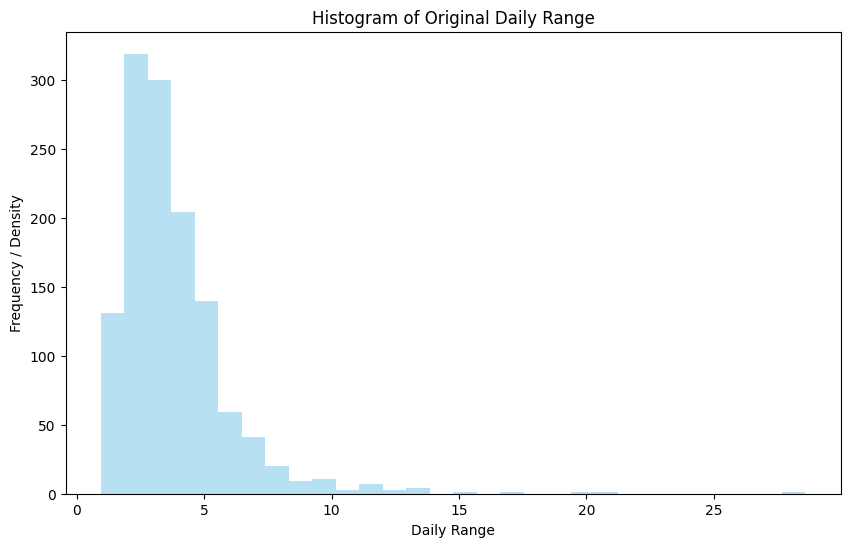

In [35]:
import numpy as np
import matplotlib.pyplot as plt

# Original Daily Range
plt.figure(figsize=(10,6))
plt.hist(data['Daily_Range'], bins=30, color='skyblue', alpha=0.6)
plt.title("Histogram of Original Daily Range")
plt.xlabel("Daily Range")
plt.ylabel("Frequency / Density")
plt.show()

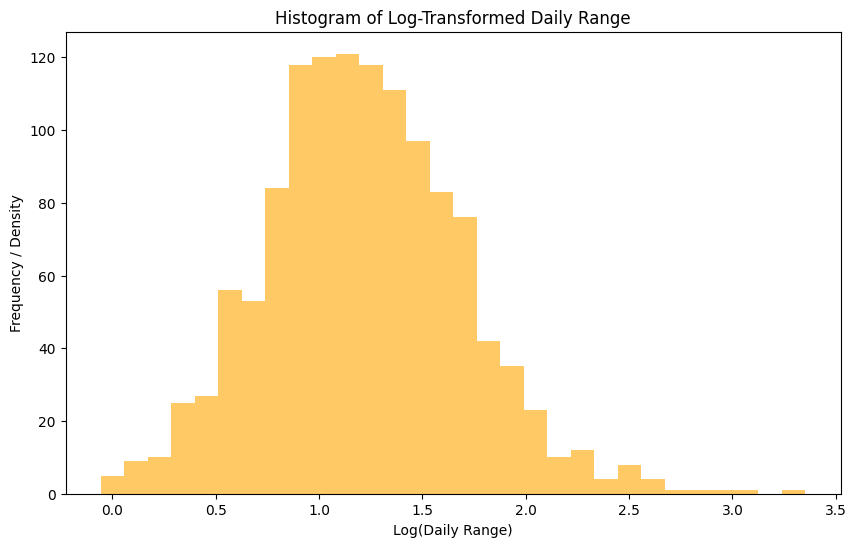

In [36]:
# Log-transformed Daily Range
data['Daily_Range_log'] = np.log(data['Daily_Range'] + 1e-6)

plt.figure(figsize=(10,6))
plt.hist(data['Daily_Range_log'], bins=30, color='orange', alpha=0.6)
plt.title("Histogram of Log-Transformed Daily Range")
plt.xlabel("Log(Daily Range)")
plt.ylabel("Frequency / Density")
plt.show()

<Figure size 1000x600 with 0 Axes>

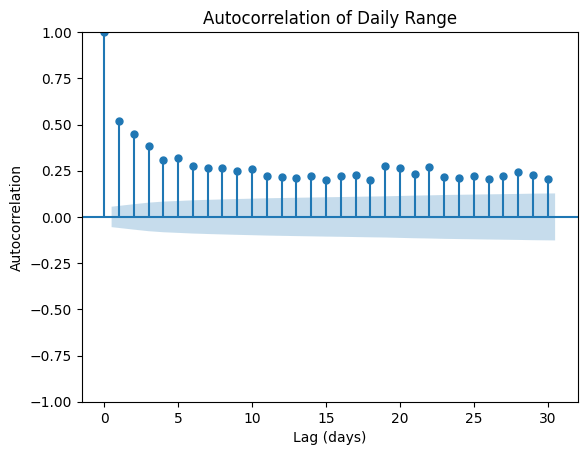

In [44]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

# Use original Daily Range
daily_range = data['Daily_Range']

# Plot autocorrelation
plt.figure(figsize=(10,6))
plot_acf(daily_range, lags=30)  # check autocorrelation for 30 previous days
plt.title('Autocorrelation of Daily Range')
plt.xlabel('Lag (days)')
plt.ylabel('Autocorrelation')
plt.show()

<Figure size 1000x600 with 0 Axes>

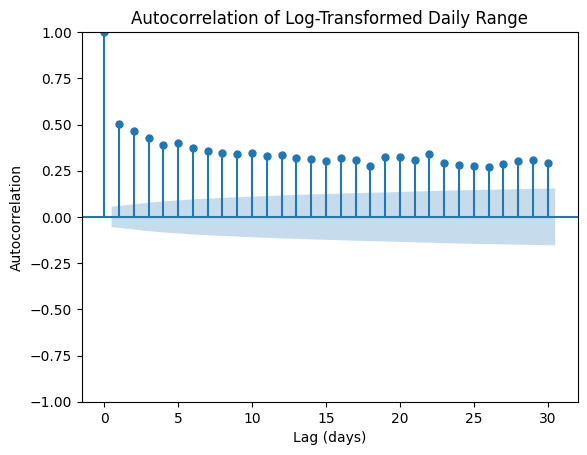

In [46]:
#Autocorrelation for log transformed data

import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
import numpy as np

# Make sure Daily_Range_log exists
data['Daily_Range_log'] = np.log(data['Daily_Range'] + 1e-6)  # tiny constant to avoid log(0)

# Plot autocorrelation
plt.figure(figsize=(10,6))
plot_acf(data['Daily_Range_log'], lags=30)  # check autocorrelation for 30 previous days
plt.title('Autocorrelation of Log-Transformed Daily Range')
plt.xlabel('Lag (days)')
plt.ylabel('Autocorrelation')
plt.show()

In [47]:
import numpy as np

# Use original Daily Range
daily_range = data['Daily_Range'].values  # convert to NumPy array

# Number of observations
n = len(daily_range)

# MLE estimate for mean
mu_mle = np.mean(daily_range)

# MLE estimate for variance
sigma2_mle = np.sum((daily_range - mu_mle)**2) / n

print("MLE estimate of μ (mean):", mu_mle)
print("MLE estimate of σ² (variance):", sigma2_mle)

MLE estimate of μ (mean): 3.7975592353854997
MLE estimate of σ² (variance): 4.7633601018755485


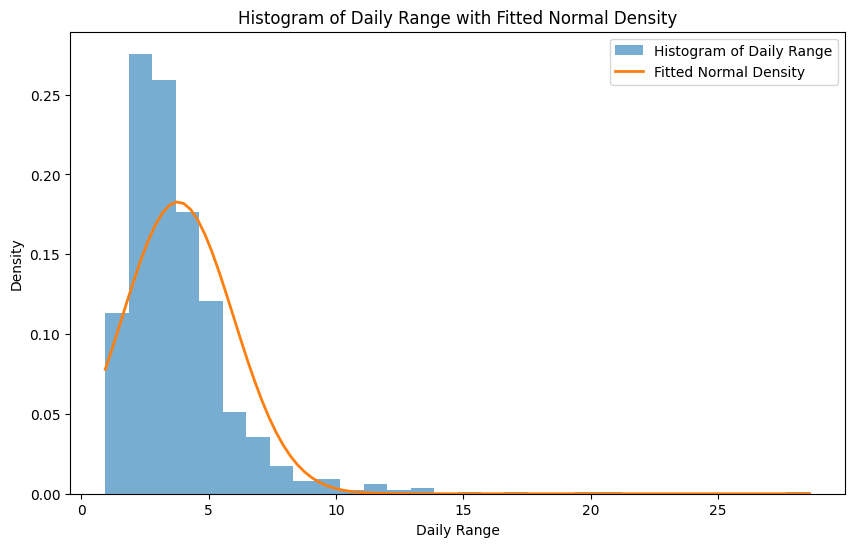

In [48]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Extract Daily Range
daily_range = data['Daily_Range']

# MLE estimates
mu = np.mean(daily_range)
sigma = np.sqrt(np.sum((daily_range - mu)**2) / len(daily_range))  # sqrt of variance

# Plot histogram
plt.figure(figsize=(10,6))
plt.hist(daily_range, bins=30, density=True, alpha=0.6, label='Histogram of Daily Range')

# Generate x values for normal curve
x = np.linspace(daily_range.min(), daily_range.max(), 100)

# Plot fitted normal density
plt.plot(x, norm.pdf(x, mu, sigma), linewidth=2, label='Fitted Normal Density')

# Labels
plt.title("Histogram of Daily Range with Fitted Normal Density")
plt.xlabel("Daily Range")
plt.ylabel("Density")
plt.legend()

plt.show()

In [51]:
#Regression Model
import statsmodels.api as sm

# Define predictors (X)
X = data[['Daily_Range', 'Volume']]

# Add constant for intercept
X = sm.add_constant(X)

# Define response variable (Y)
Y = data['Close']

# Fit regression model
model = sm.OLS(Y, X).fit()

# Show regression results
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   AAPL   R-squared:                       0.451
Model:                            OLS   Adj. R-squared:                  0.450
Method:                 Least Squares   F-statistic:                     514.8
Date:                Sat, 14 Mar 2026   Prob (F-statistic):          6.54e-164
Time:                        16:30:34   Log-Likelihood:                -6090.6
No. Observations:                1256   AIC:                         1.219e+04
Df Residuals:                    1253   BIC:                         1.220e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                 210.3388    

In [54]:
# testing the coefficients

import statsmodels.api as sm

# Define predictors
X = data[['Daily_Range', 'Volume']]

# Add intercept
X = sm.add_constant(X)

# Define response variable
Y = data['Close']

# Fit regression model
model = sm.OLS(Y, X).fit()

# Print full regression summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   AAPL   R-squared:                       0.451
Model:                            OLS   Adj. R-squared:                  0.450
Method:                 Least Squares   F-statistic:                     514.8
Date:                Sat, 14 Mar 2026   Prob (F-statistic):          6.54e-164
Time:                        16:41:31   Log-Likelihood:                -6090.6
No. Observations:                1256   AIC:                         1.219e+04
Df Residuals:                    1253   BIC:                         1.220e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                 210.3388    

In [55]:
print("Coefficients:\n", model.params)
print("\nT-statistics:\n", model.tvalues)
print("\nP-values:\n", model.pvalues)

Coefficients:
 const              2.103388e+02
(Daily_Range, )    1.002272e+01
(Volume, AAPL)    -9.456143e-07
dtype: float64

T-statistics:
 const              88.167725
(Daily_Range, )    23.391402
(Volume, AAPL)    -28.909976
dtype: float64

P-values:
 const               0.000000e+00
(Daily_Range, )    1.059189e-100
(Volume, AAPL)     3.191218e-141
dtype: float64
